CALIFORNIA HOUSING DATASET

First Five Records
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  

Dataset Shape
(20640, 9)

Column Names
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'HousePrice']

Data Types
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     f

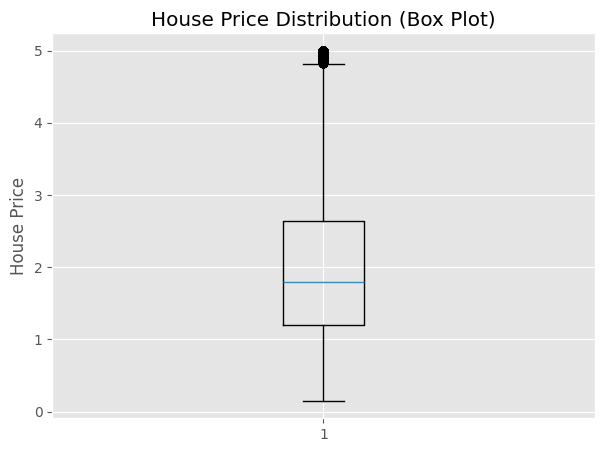

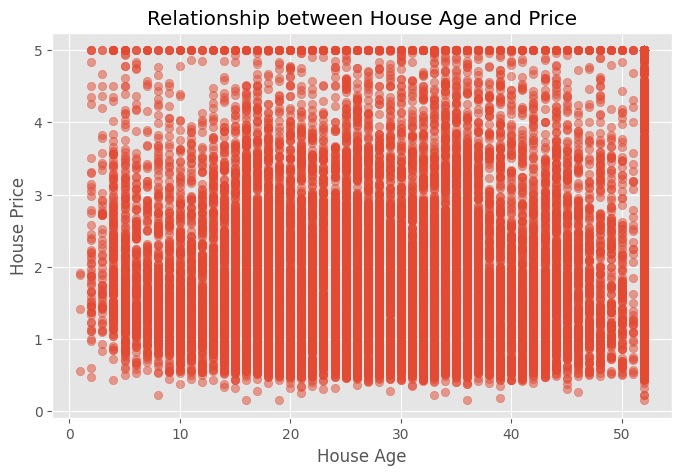

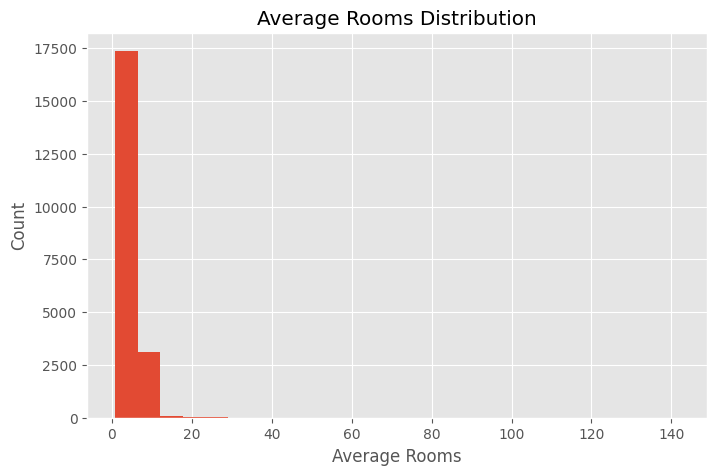

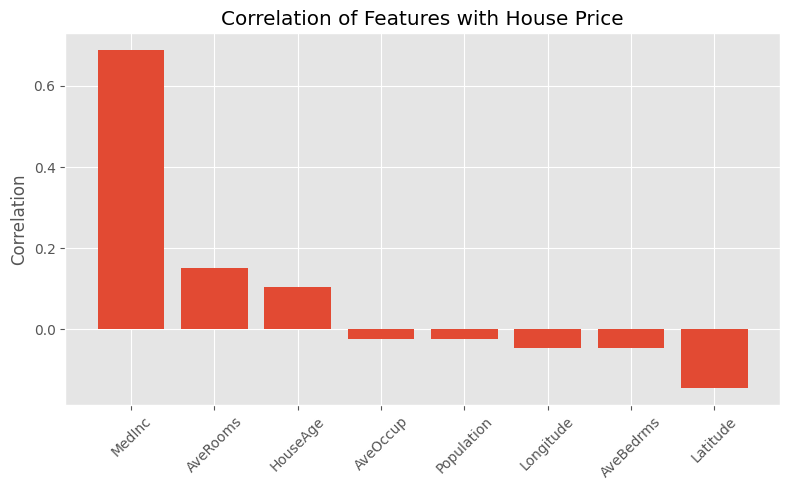


Features Shape : (20640, 8)
Target Shape : (20640,)

Applying StandardScaler...
Feature Scaling Completed

Training Samples : (16512, 8)
Testing Samples : (4128, 8)

Data is Ready for Model Training

MODEL TRAINING

Linear Regression completed successfully.
RMSE     : 0.7456
R² Score : 0.5758

Ridge Regression completed successfully.
RMSE     : 0.7456
R² Score : 0.5758

Decision Tree Regressor completed successfully.
RMSE     : 0.7052
R² Score : 0.6205


MODEL PERFORMANCE COMPARISON
 Rank                   Model   RMSE  R2 Score
    1 Decision Tree Regressor 0.7052    0.6205
    2        Ridge Regression 0.7456    0.5758
    3       Linear Regression 0.7456    0.5758

BEST MODEL
Selected Model : Decision Tree Regressor
RMSE           : 0.7052
R² Score       : 0.6205

First 10 Predictions
   Actual Price  Predicted Price
0         0.477            1.115
1         0.458            1.150
2         5.000            3.785
3         2.186            2.313
4         2.780            1.513
5 

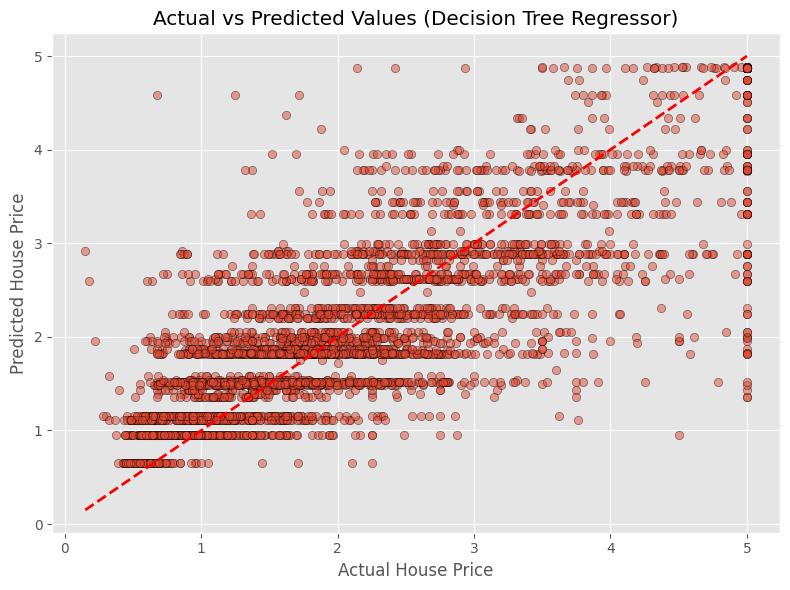

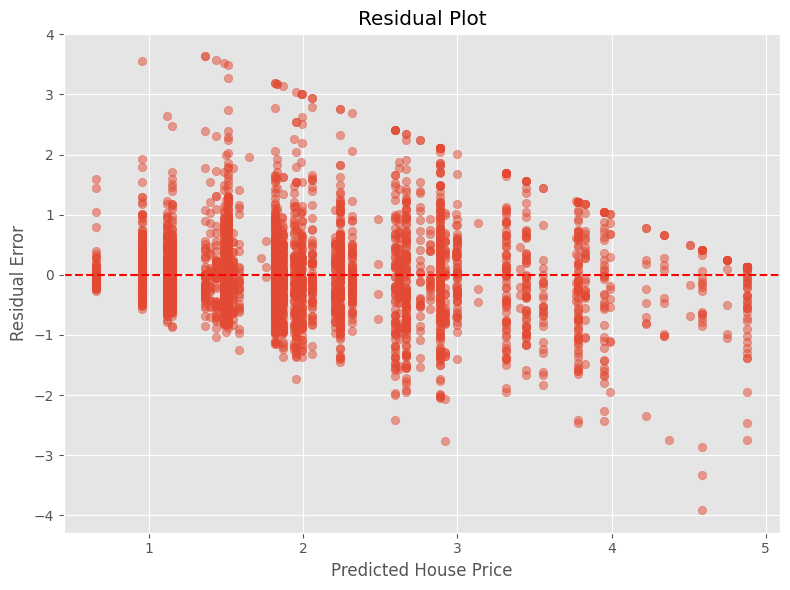

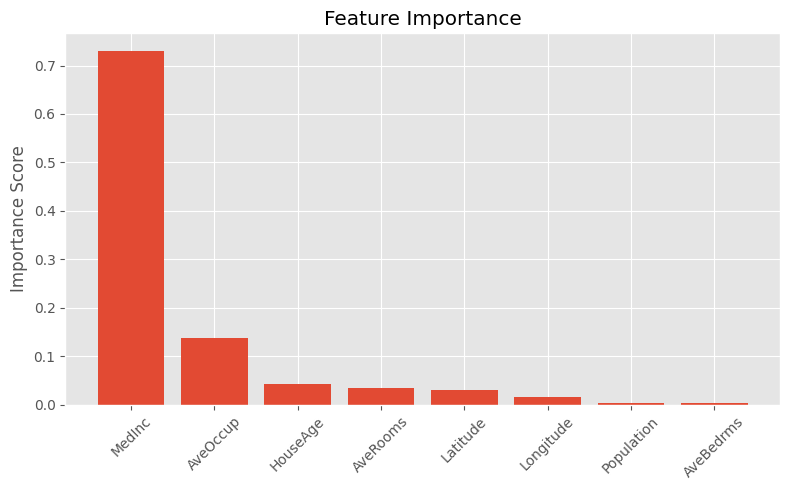


Feature Importance
      Feature  Importance
0      MedInc       0.730
5    AveOccup       0.138
1    HouseAge       0.044
2    AveRooms       0.034
6    Latitude       0.030
7   Longitude       0.017
4  Population       0.004
3   AveBedrms       0.003

Model Saved Successfully!
Filename : best_house_price_model.pkl

Predicted House Price
$488,188.05


PROJECT SUMMARY
       Category                      Details
        Dataset           California Housing
        Scaling               StandardScaler
Models Compared Linear, Ridge, Decision Tree
     Best Model      Decision Tree Regressor
     Model File   best_house_price_model.pkl


In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

# Set plot style
plt.style.use("ggplot")

#Load Dataset
print("="*60)
print("CALIFORNIA HOUSING DATASET")
print("="*60)

housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["HousePrice"] = housing.target

print("\nFirst Five Records")
print(df.head())

#Dataset Information

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nChecking Missing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe().round(2))

#Exploratory Data Analysis

# Box Plot

plt.figure(figsize=(7,5))

plt.boxplot(df["HousePrice"], vert=True)

plt.title("House Price Distribution (Box Plot)")
plt.ylabel("House Price")

plt.show()

# House Age vs Price

plt.figure(figsize=(8,5))

plt.scatter(
    df["HouseAge"],
    df["HousePrice"],
    alpha=0.5
)

plt.xlabel("House Age")

plt.ylabel("House Price")

plt.title("Relationship between House Age and Price")

plt.show()

# Average Rooms Distribution

plt.figure(figsize=(8,5))

plt.hist(
    df["AveRooms"],
    bins=25
)

plt.title("Average Rooms Distribution")

plt.xlabel("Average Rooms")

plt.ylabel("Count")

plt.show()

# Feature Correlation Bar Chart

correlation = df.corr()["HousePrice"].sort_values(
    ascending=False
)

correlation = correlation.drop("HousePrice")

plt.figure(figsize=(8,5))

plt.bar(
    correlation.index,
    correlation.values
)

plt.xticks(rotation=45)

plt.ylabel("Correlation")

plt.title("Correlation of Features with House Price")

plt.tight_layout()

plt.show()

#Prepare Features and Target

X = df.drop("HousePrice", axis=1)

y = df["HousePrice"]

print("\nFeatures Shape :", X.shape)

print("Target Shape :", y.shape)

#Feature Scaling

print("\nApplying StandardScaler...")

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

#Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,

    y,

    test_size=0.20,

    random_state=42

)

print("\nTraining Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

print("\nData is Ready for Model Training")

#Train Multiple Regression Models

print("\n" + "="*60)
print("MODEL TRAINING")
print("="*60)

# Dictionary containing all models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=6,
        random_state=42
    )
}

# Store trained models
trained_models = {}

# Store evaluation results
model_results = []

# Function to Train and Evaluate Model

def evaluate_model(model_name, model):

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    predictions = model.predict(X_test)

    # Evaluation Metrics
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    # Store trained model
    trained_models[model_name] = model

    # Store results
    model_results.append({
        "Model": model_name,
        "RMSE": rmse,
        "R2 Score": r2
    })

    print(f"\n{model_name} completed successfully.")
    print(f"RMSE     : {rmse:.4f}")
    print(f"R² Score : {r2:.4f}")

# ==========================================================
# Train All Models
# ==========================================================

for name, model in models.items():
    evaluate_model(name, model)

# ==========================================================
# STEP 8 : Compare Model Performance
# ==========================================================

results_df = pd.DataFrame(model_results)

# Rank based on highest R² Score
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

# Add ranking column
results_df.insert(
    0,
    "Rank",
    range(1, len(results_df)+1)
)

print("\n")
print("="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)

print(results_df.round(4).to_string(index=False))

# ==========================================================
# STEP 9 : Select Best Model
# ==========================================================

best_model_name = results_df.loc[0, "Model"]

best_model = trained_models[best_model_name]

print("\n" + "="*60)
print("BEST MODEL")
print("="*60)

print(f"Selected Model : {best_model_name}")
print(f"RMSE           : {results_df.loc[0,'RMSE']:.4f}")
print(f"R² Score       : {results_df.loc[0,'R2 Score']:.4f}")

# Predict using the best model
best_predictions = best_model.predict(X_test)

print("\nFirst 10 Predictions")

prediction_table = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": best_predictions[:10]
})

print(prediction_table.round(3))

# ==========================================================
# STEP 10 : Visualize Best Model Performance
# ==========================================================

print("\nGenerating Model Visualizations...")

# Actual vs Predicted Plot

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5,
    edgecolors="black"
)

# Perfect Prediction Line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2,
    linestyle="--"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title(f"Actual vs Predicted Values ({best_model_name})")

plt.grid(True)

plt.tight_layout()

plt.show()


# ==========================================================
# STEP 11 : Residual Plot
# ==========================================================

residuals = y_test - best_predictions

plt.figure(figsize=(8,6))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted House Price")
plt.ylabel("Residual Error")

plt.title("Residual Plot")

plt.grid(True)

plt.tight_layout()

plt.show()


# ==========================================================
# STEP 12 : Feature Importance
# (Only if Decision Tree is the Best Model)
# ==========================================================

if best_model_name == "Decision Tree Regressor":

    importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": best_model.feature_importances_

    })

    importance = importance.sort_values(

        by="Importance",

        ascending=False

    )

    plt.figure(figsize=(8,5))

    plt.bar(
        importance["Feature"],
        importance["Importance"]
    )

    plt.xticks(rotation=45)

    plt.ylabel("Importance Score")

    plt.title("Feature Importance")

    plt.tight_layout()

    plt.show()

    print("\nFeature Importance")

    print(importance.round(3))


# ==========================================================
# STEP 13 : Save Best Model
# ==========================================================

import joblib

joblib.dump(

    best_model,

    "best_house_price_model.pkl"

)

print("\nModel Saved Successfully!")

print("Filename : best_house_price_model.pkl")


# ==========================================================
# STEP 14 : Predict House Price
# ==========================================================

sample_house = pd.DataFrame(

    [[8.32,
      41,
      6.98,
      1.02,
      322,
      2.55,
      37.88,
      -122.23]],

    columns=X.columns

)

sample_scaled = scaler.transform(sample_house)

predicted_price = best_model.predict(sample_scaled)

print("\nPredicted House Price")

print(f"${predicted_price[0]*100000:,.2f}")


# ==========================================================
# STEP 15 : Project Summary
# ==========================================================

summary = pd.DataFrame({

    "Category":[

        "Dataset",

        "Scaling",

        "Models Compared",

        "Best Model",

        "Model File"

    ],

    "Details":[

        "California Housing",

        "StandardScaler",

        "Linear, Ridge, Decision Tree",

        best_model_name,

        "best_house_price_model.pkl"

    ]

})

print("\n")

print("="*60)

print("PROJECT SUMMARY")

print("="*60)

print(summary.to_string(index=False))
